In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import opendatasets as od
from sklearn.naive_bayes import MultinomialNB,GaussianNB

In [2]:
od.download("https://www.kaggle.com/datasets/uniquetech/classroom-air-quality")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/uniquetech/classroom-air-quality


100%|██████████| 7.95k/7.95k [00:00<00:00, 2.72MB/s]

In [12]:
df = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Music\\NTI\\classroom-air-quality\\unique_tech_classroom_air_quality.csv",parse_dates=['timestamp'])

In [13]:
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
0,2025-11-12 08:00:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good
1,2025-11-12 08:01:42,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good
2,2025-11-12 08:03:24,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good
3,2025-11-12 08:05:06,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good
4,2025-11-12 08:06:48,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                500 non-null    datetime64[ns]
 1   school_period            500 non-null    object        
 2   student_count_estimated  500 non-null    int64         
 3   co2_ppm                  500 non-null    float64       
 4   pm25_ugm3                500 non-null    float64       
 5   temperature_c            500 non-null    float64       
 6   humidity_pct             500 non-null    float64       
 7   robot_x_pos              500 non-null    float64       
 8   robot_y_pos              500 non-null    float64       
 9   ventilation_decision     500 non-null    object        
 10  air_quality_label        500 non-null    object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(3)
memory usage: 43.1+ KB


In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'school_period': ['Morning Entry' '1st Period' '2nd Period' 'Break' '3rd Period'
 '4th Period' 'Lunch Break' '5th Period' 'End of Day']
Unique values in 'ventilation_decision': ['IDLE' 'MONITOR']
Unique values in 'air_quality_label': ['Good' 'Moderate']


In [23]:
 df.drop(columns =['ventilation_decision'], inplace = True)

In [24]:
df.describe()

,timestamp,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,2025-11-12 15:04:08.999999744,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
min,2025-11-12 08:00:00,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,2025-11-12 11:32:04.500000,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,2025-11-12 15:04:09,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,2025-11-12 18:36:13.500000,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,2025-11-12 22:08:18,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000
std,NaN,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781


In [27]:
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        nbins=50,
        template='plotly_dark',
        title=f'Histogram of {col}',
        labels={col: col},
    )
    fig.update_layout(
        plot_bgcolor='black',
        paper_bgcolor='black',
        font_color='white',
    )
    fig.show()

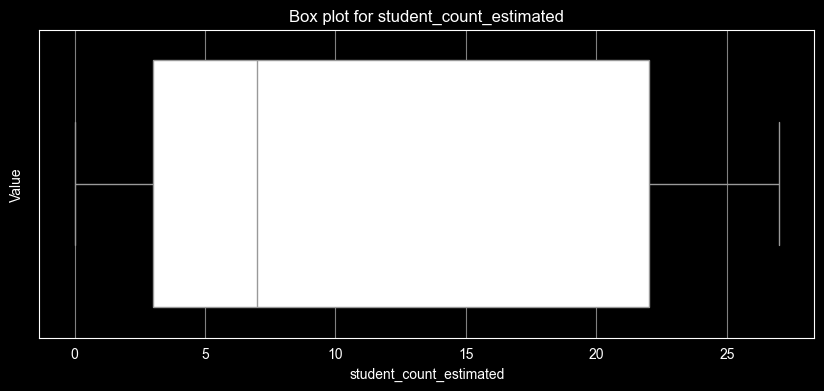

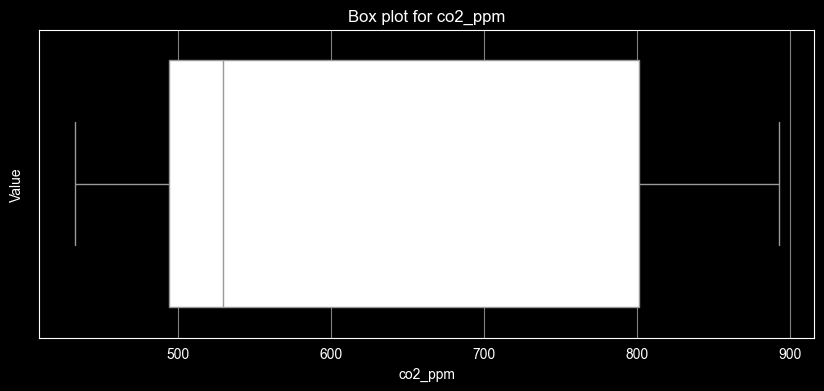

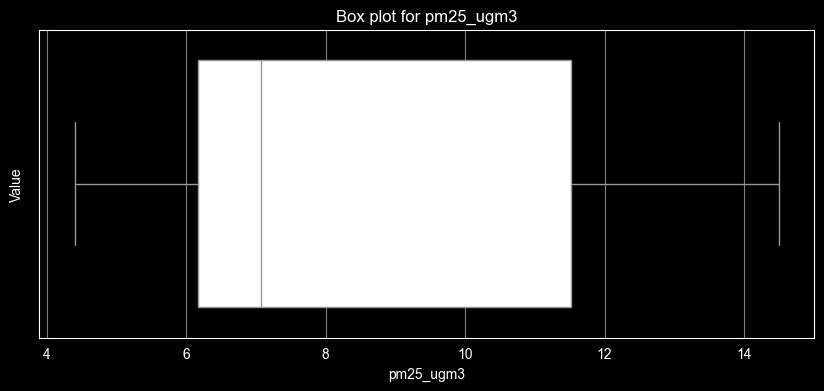

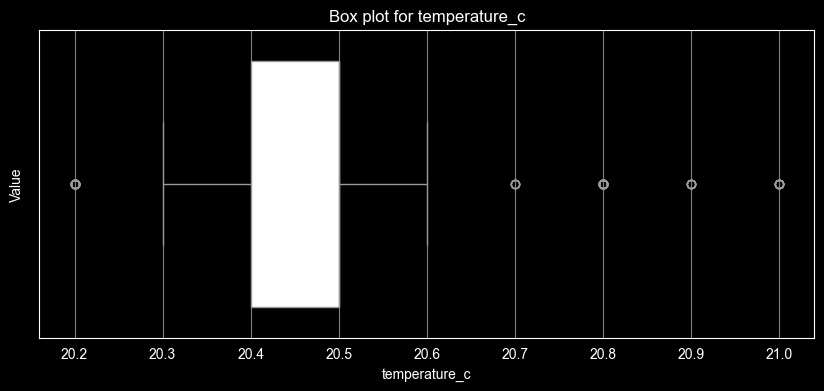

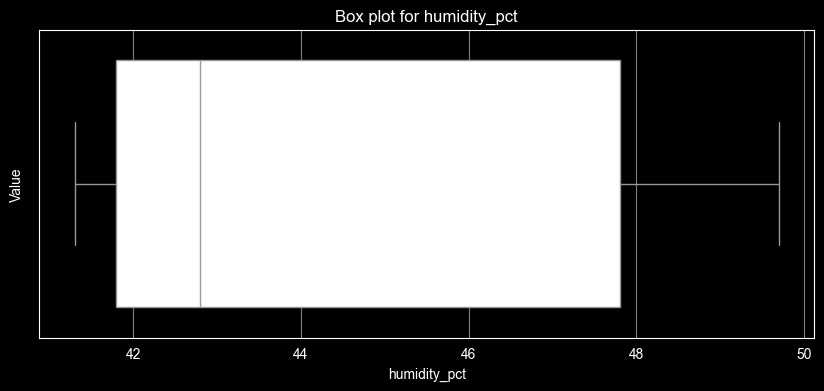

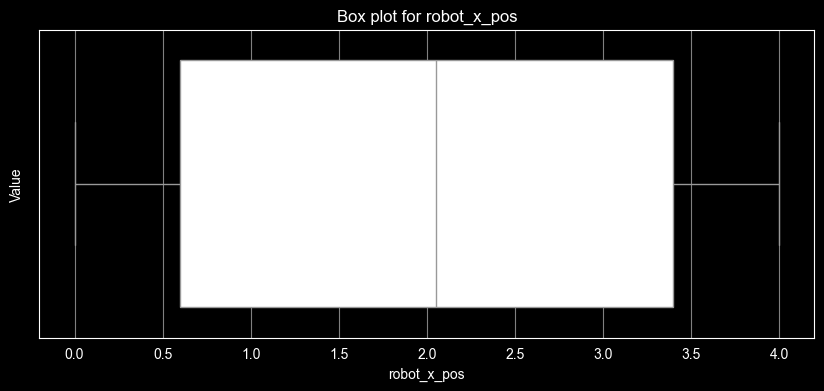

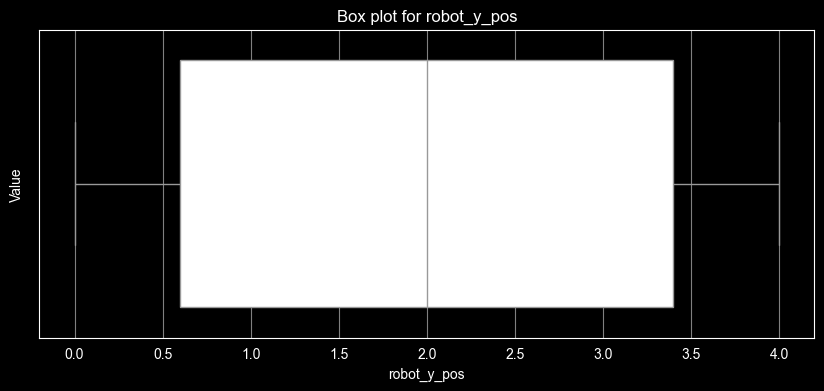

In [29]:
sns.set_style("darkgrid", {
    "axes.facecolor": "black",
    "figure.facecolor": "black",
    "grid.color": "gray",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
})
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["axes.edgecolor"] = "white"
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["figure.edgecolor"] = "black"

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], color="#ffffff")
    plt.title(f"Box plot for {col}", color="white")
    plt.xlabel(col)
    plt.ylabel("Value")
    plt.gca().patch.set_facecolor('black')
    plt.show()

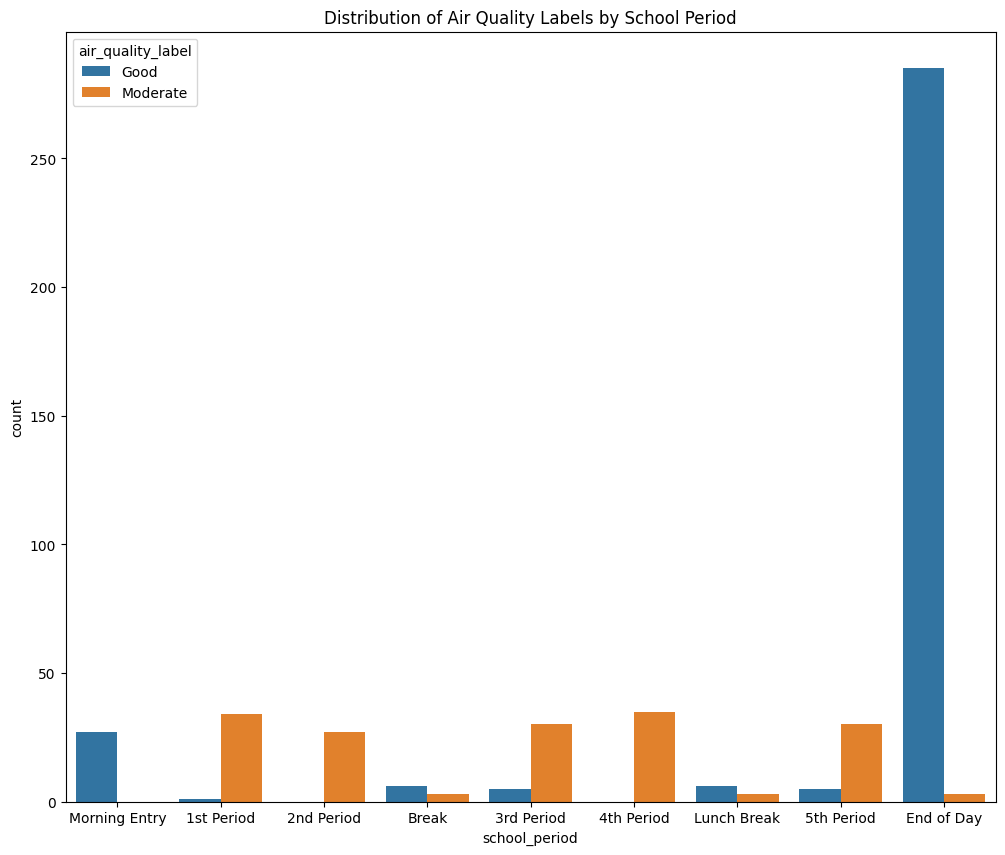

In [28]:
plt.figure(figsize=(12, 10))
sns.countplot(data=df,x='school_period',hue='air_quality_label')
plt.title('Distribution of Air Quality Labels by School Period')
plt.show()

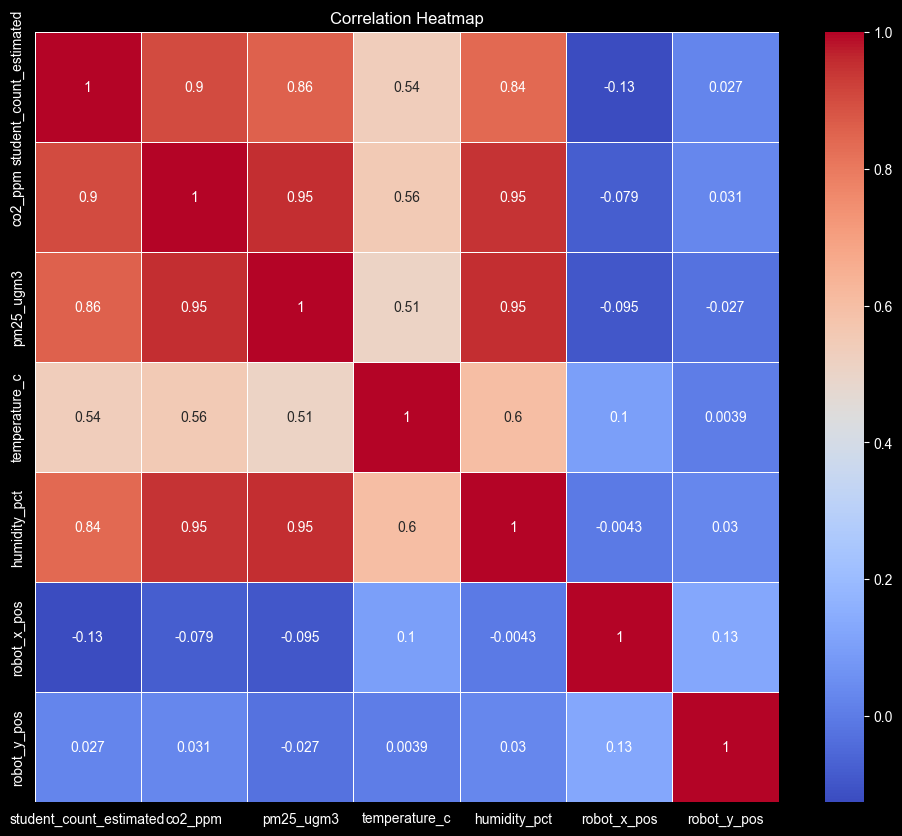

In [30]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [38]:

df['year'] = X['timestamp'].dt.year
df['month'] = X['timestamp'].dt.month
df['day'] = X['timestamp'].dt.day
df['hour'] = X['timestamp'].dt.hour  

df.drop(columns=['timestamp'], inplace=True)

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        84
           1       0.93      1.00      0.96        41

    accuracy                           0.98       125
   macro avg       0.97      0.98      0.97       125
weighted avg       0.98      0.98      0.98       125

Confusion matrix:
[[81  3]
 [ 0 41]]


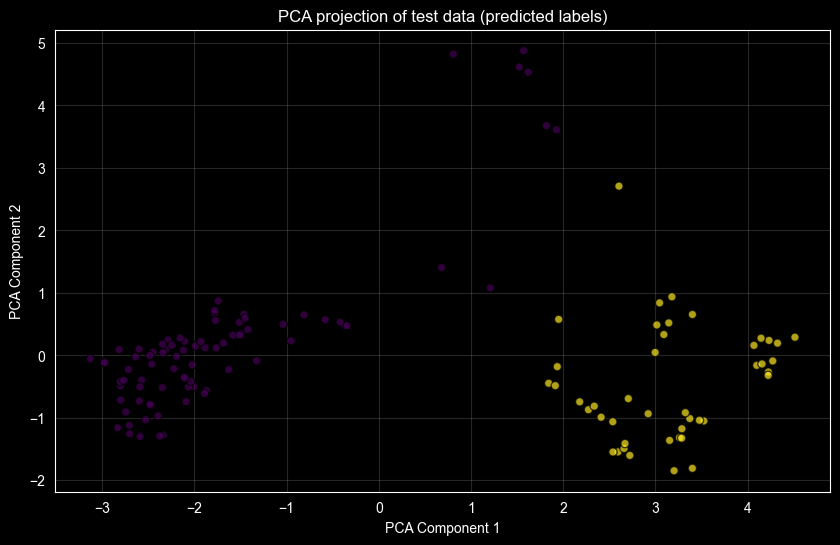

In [39]:
# Encode categorical variables and prepare target
TARGET_COLUMN = 'air_quality_label'
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype('category').cat.codes

# One-hot encode categorical inputs, excluding the target
X_encoded = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Reduce dimensionality with PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.25, random_state=42, stratify=y
)

# Fit Gaussian Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Evaluate
y_pred = nb_model.predict(X_test)
print('Classification report:')
print(classification_report(y_test, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

# Plot PCA projection with predicted vs actual labels
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('PCA projection of test data (predicted labels)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, color='gray', alpha=0.3)
plt.show()